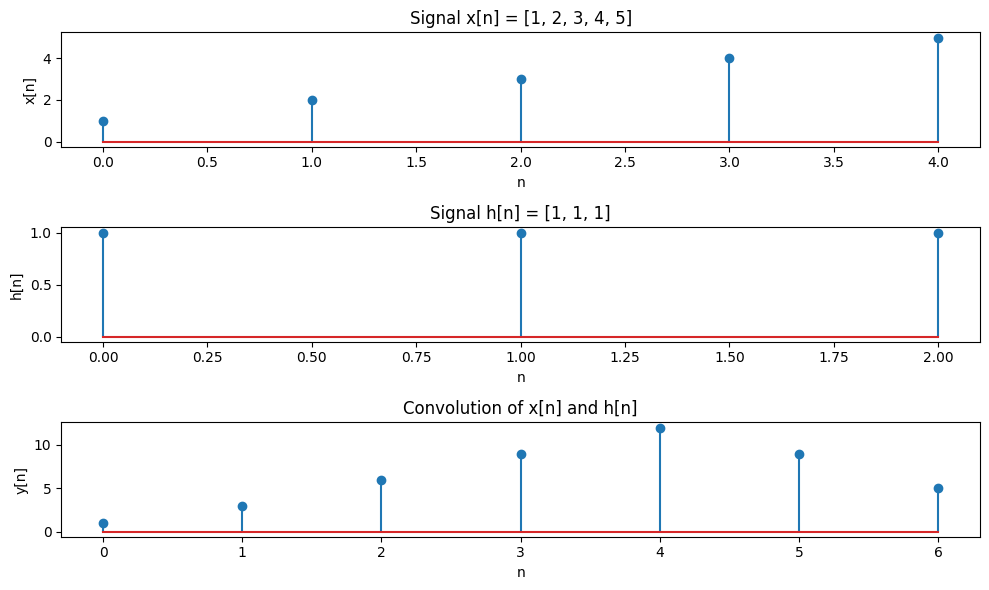

In [2]:
import numpy as np
import matplotlib.pyplot as plt


x_n = np.array([1, 2, 3, 4, 5])
h_n = np.array([1, 1, 1])


y_n = np.convolve(x_n, h_n, mode='full')


n_x = np.arange(len(x_n))
n_h = np.arange(len(h_n))
n_y = np.arange(len(y_n))


plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.stem(n_x, x_n)
plt.title('Signal x[n] = [1, 2, 3, 4, 5]')
plt.xlabel('n')
plt.ylabel('x[n]')

plt.subplot(3, 1, 2)
plt.stem(n_h, h_n)
plt.title('Signal h[n] = [1, 1, 1]')
plt.xlabel('n')
plt.ylabel('h[n]')

plt.subplot(3, 1, 3)
plt.stem(n_y, y_n)
plt.title('Convolution of x[n] and h[n]')
plt.xlabel('n')
plt.ylabel('y[n]')

plt.tight_layout()
plt.show()


## Task 2

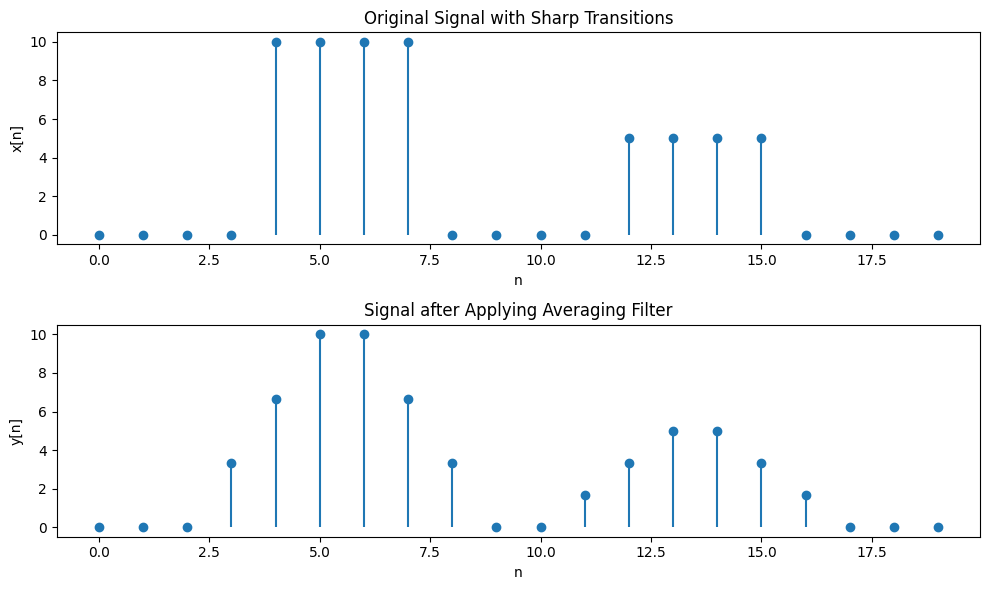

In [3]:
import numpy as np
import matplotlib.pyplot as plt


n = np.arange(0, 20)
x_n = np.array([0, 0, 0, 0, 10, 10, 10, 10, 0, 0, 0, 0, 5, 5, 5, 5, 0, 0, 0, 0])  # Sharp transitions

#the averaging filter (e.g., 3-point moving average filter)
filter_kernel = np.ones(3) / 3

#averaging filter using convolution
y_n = np.convolve(x_n, filter_kernel, mode='same')

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.stem(n, x_n, basefmt=" ")
plt.title('Original Signal with Sharp Transitions')
plt.xlabel('n')
plt.ylabel('x[n]')

plt.subplot(2, 1, 2)
plt.stem(n, y_n, basefmt=" ")
plt.title('Signal after Applying Averaging Filter')
plt.xlabel('n')
plt.ylabel('y[n]')

plt.tight_layout()
plt.show()


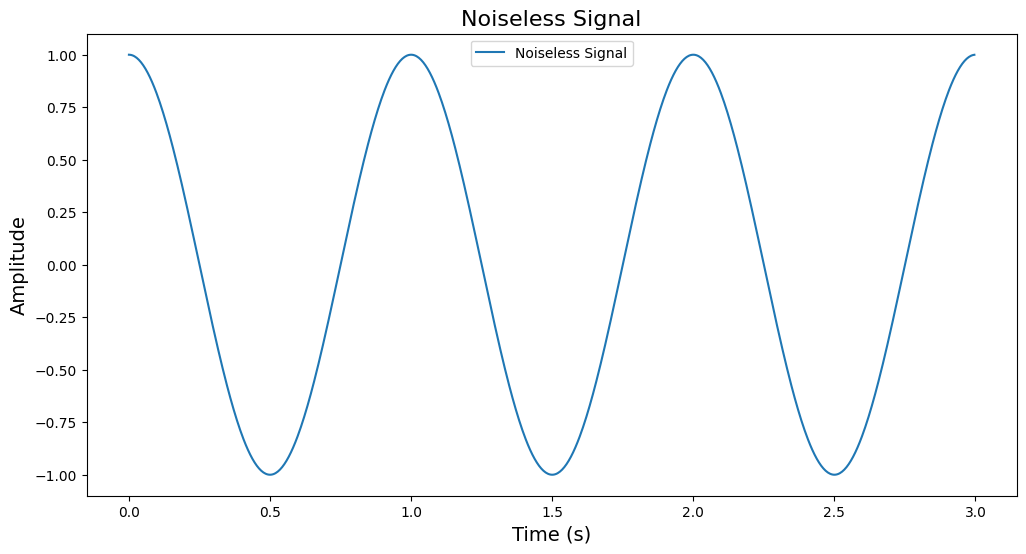

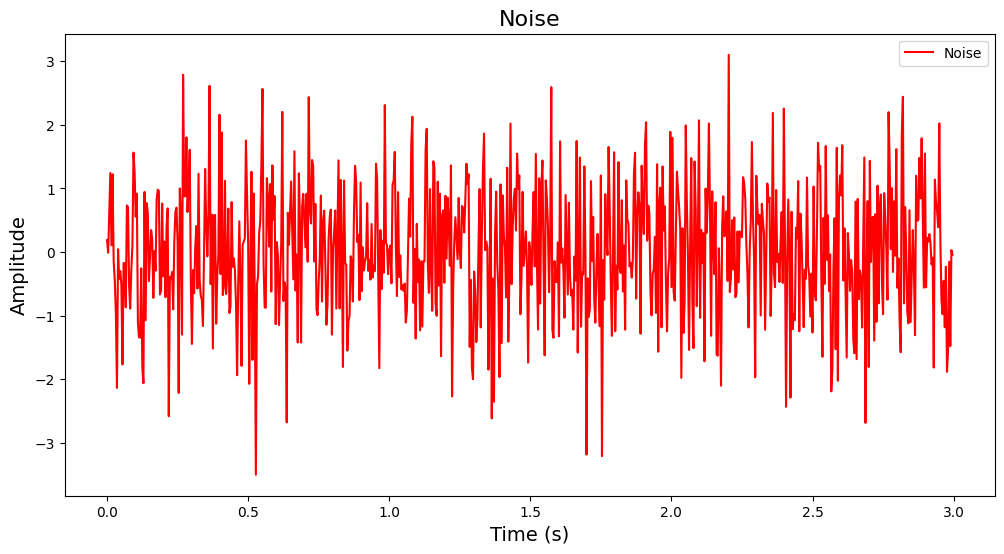

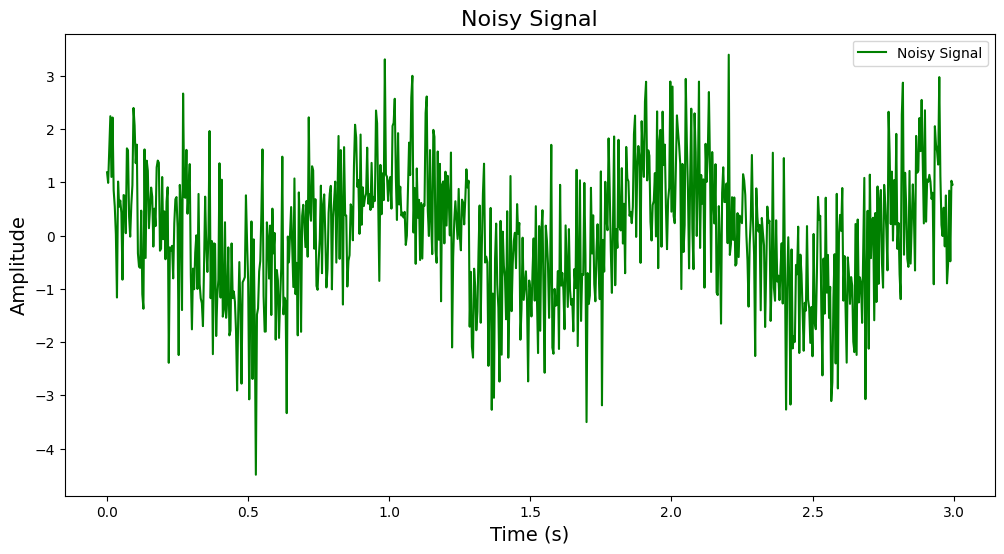

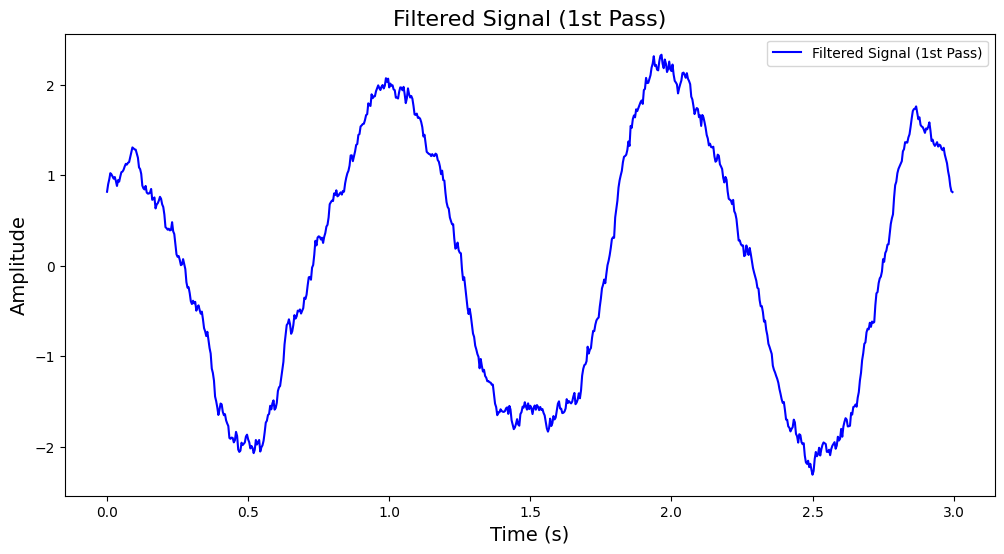

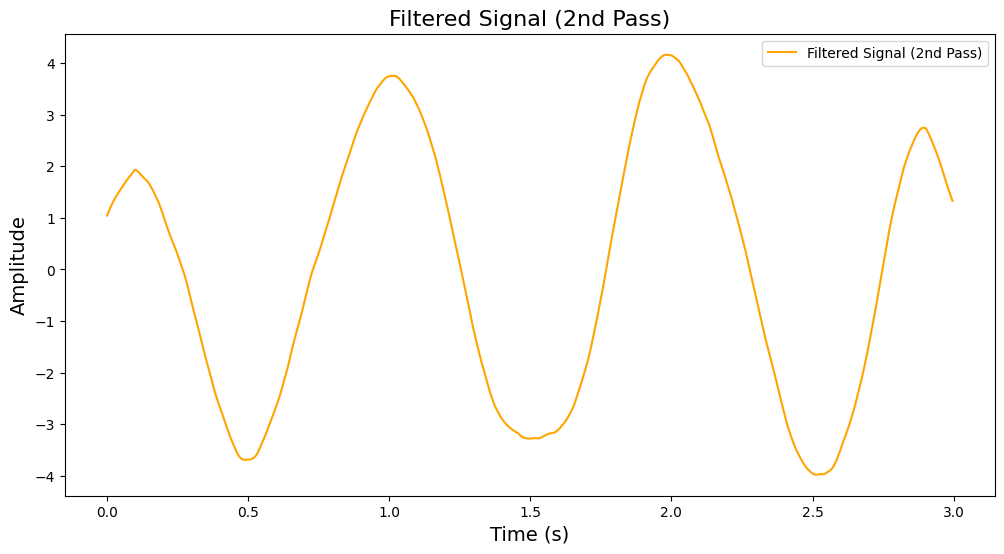

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling rate and time vector
Srate = 256  # Hz
t = np.arange(0, 3, 1/Srate)
pnts = len(t)

# Create a noiseless signal (cosine wave)
x = np.cos(2 * np.pi * 1 * t)

# Plot the noiseless signal
plt.figure(figsize=(12, 6))
plt.plot(t, x, label='Noiseless Signal')
plt.title('Noiseless Signal', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()

# Generate random noise
noise = np.random.randn(pnts)

# Plot the noise
plt.figure(figsize=(12, 6))
plt.plot(t, noise, label='Noise', color='r')
plt.title('Noise', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()

# Create the noisy signal by adding noise to the cosine wave
NoisySignal = x + noise

# Plot the noisy signal
plt.figure(figsize=(12, 6))
plt.plot(t, NoisySignal, label='Noisy Signal', color='g')
plt.title('Noisy Signal', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()

# Define the filter (simple moving average)
filter_kernel = 2 * np.ones(50) / 50.0

# Apply the filter using convolution
filteredSignal = np.convolve(NoisySignal, filter_kernel, mode='same')

# Plot the filtered signal
plt.figure(figsize=(12, 6))
plt.plot(t, filteredSignal, label='Filtered Signal (1st Pass)', color='b')
plt.title('Filtered Signal (1st Pass)', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()

# Apply the filter again to the already filtered signal (2nd pass)
filteredSignal2 = np.convolve(filteredSignal, filter_kernel, mode='same')

# Plot the doubly filtered signal
plt.figure(figsize=(12, 6))
plt.plot(t, filteredSignal2, label='Filtered Signal (2nd Pass)', color='orange')
plt.title('Filtered Signal (2nd Pass)', fontsize=16)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend()
plt.show()


# Task 4

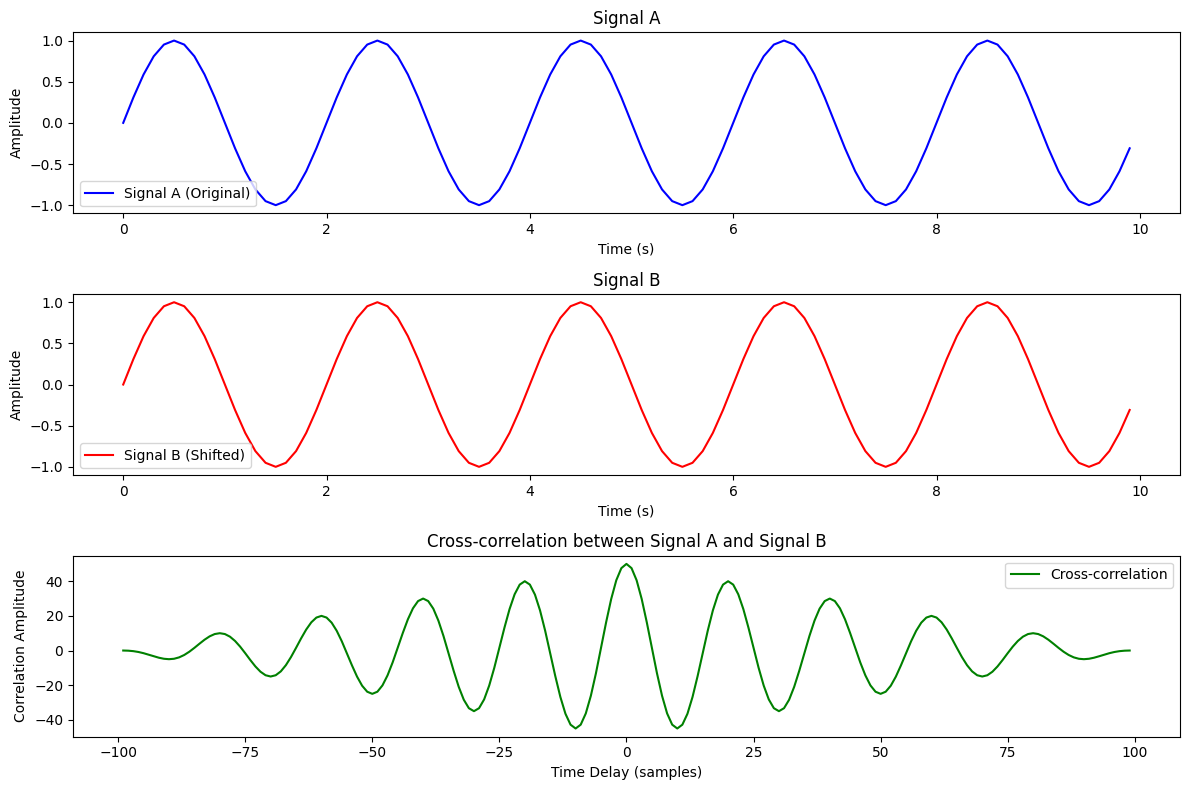

In [7]:
import numpy as np
import matplotlib.pyplot as plt


t = np.arange(0, 10, 0.1)
signal_A = np.sin(2 * np.pi * 0.5 * t)
signal_B = np.sin(2 * np.pi * 0.5 * (t - 2))


correlation = np.correlate(signal_A, signal_B, mode='full')


lag = np.arange(-len(t) + 1, len(t))


plt.figure(figsize=(12, 8))

# Signal A
plt.subplot(3, 1, 1)
plt.plot(t, signal_A, label="Signal A (Original)", color='b')
plt.title("Signal A")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Signal B
plt.subplot(3, 1, 2)
plt.plot(t, signal_B, label="Signal B (Shifted)", color='r')
plt.title("Signal B")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Cross-correlation
plt.subplot(3, 1, 3)
plt.plot(lag, correlation, label="Cross-correlation", color='g')
plt.title("Cross-correlation between Signal A and Signal B")
plt.xlabel("Time Delay (samples)")
plt.ylabel("Correlation Amplitude")
plt.legend()

plt.tight_layout()
plt.show()
